In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [3]:
df = pd.DataFrame({
    'Temperature': [1, 2, 3, 4, 5, 6, 7, 8],
    'Energy Consumption': [2,5,9,15,14,10,5,1]
    
})

Text(0.5, 1.0, 'Temperature vs Energy Consumption')

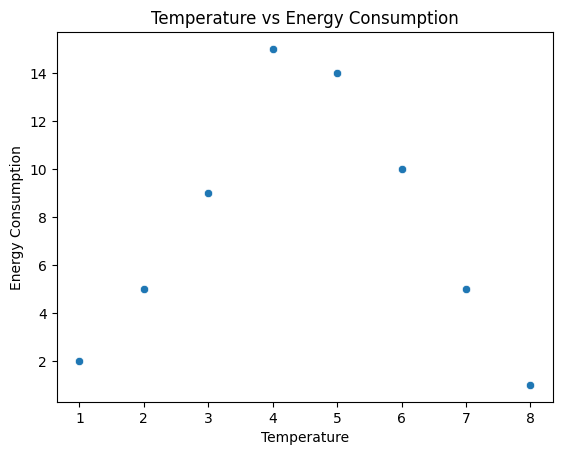

In [4]:
sns.scatterplot(x='Temperature', y='Energy Consumption', data=df)
plt.title('Temperature vs Energy Consumption')

In [5]:
# Create polynomial features
x= df[['Temperature']]
y = df['Energy Consumption']
x_poly = PolynomialFeatures(degree=2).fit_transform(x)
# Fit the polynomial regression model
model = LinearRegression().fit(x_poly, y)

print(x_poly )
#intercept and coefficients
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]
 [ 1.  7. 49.]
 [ 1.  8. 64.]]
Coefficients: [ 0.          9.10119048 -1.01785714]
Intercept: -7.3749999999999005


In [6]:
#predicting energy consumption for a given temperature
predicted_energy_consumption = model.predict(PolynomialFeatures(degree=2).fit_transform([[5]]))
print("Predicted Energy Consumption for Temperature 5:", predicted_energy_consumption[0])

Predicted Energy Consumption for Temperature 5: 12.6845238095238


In [7]:
energy = model.predict(x_poly)
print(f'energy consumption for each temperature: {energy}')

energy consumption for each temperature: [ 0.70833333  6.75595238 10.76785714 12.74404762 12.68452381 10.58928571
  6.45833333  0.29166667]


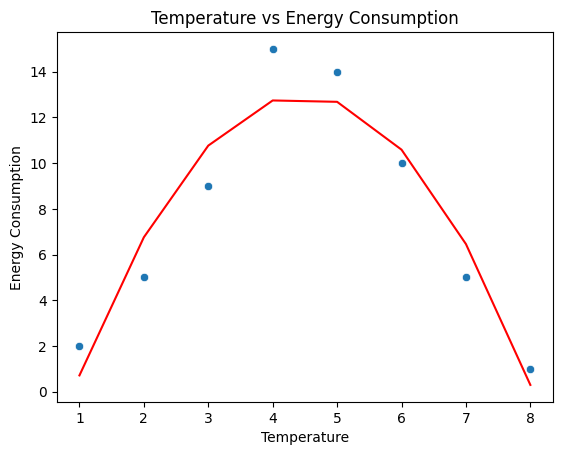

In [8]:
sns.scatterplot(x='Temperature', y='Energy Consumption', data=df)
plt.title('Temperature vs Energy Consumption')
plt.plot(x, energy, color='red')
plt.show()


In [9]:
print(x_poly)


[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]
 [ 1.  6. 36.]
 [ 1.  7. 49.]
 [ 1.  8. 64.]]


In [10]:
#calculating error 
#r squared error
r_squared = model.score(x_poly, y)
print("R-squared: {:.2f}".format(r_squared))

print(f"R-squared: {r_squared:.2f}")


R-squared: 0.91
R-squared: 0.91


In [ ]:
#calculation of mean squared error, mean absolute error r2 score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y, energy)
mae = mean_absolute_error(y, energy)
r2 = r2_score(y, energy)
print("Mean Squared Error: {:.2f}".format(mse))
print("Mean Absolute Error: {:.2f}".format(mae))
print("R-squared Score: {:.2f}".format(r2))


Mean Squared Error: 2.21
Mean Absolute Error: 1.39
R-squared Score: 0.91
